In [58]:
# Bring in NumPy and Pandas, then list all dataset files available on Kaggle
import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/aframusarratdiya/music-project-data/X_test.npy
/kaggle/input/datasets/aframusarratdiya/music-project-data/X_val.npy
/kaggle/input/datasets/aframusarratdiya/music-project-data/X_train.npy


In [59]:
# Install the pretty_midi library so we can read and write MIDI files
!pip install pretty_midi -q
print('installed!')

installed!


In [60]:
# Import everything we need: PyTorch for the model, matplotlib for plots, and pretty_midi for MIDI handling
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from collections import Counter
import pretty_midi

In [61]:
# Set up folder paths for data, saved models, generated MIDIs, and plots. Create any missing folders automatically
DATA_DIR = '/kaggle/input/datasets/aframusarratdiya/music-project-data'
MODEL_DIR  = '/kaggle/working/models'
OUTPUT_DIR = '/kaggle/working/outputs/generated_midis/task1'
PLOT_DIR   = '/kaggle/working/outputs/plots'

for d in [MODEL_DIR, OUTPUT_DIR, PLOT_DIR]:
    os.makedirs(d, exist_ok=True)

print('Kaggle setup complete!')

Kaggle setup complete!


In [62]:
# Load the pre-split piano-roll arrays, convert them to PyTorch tensors, and wrap in DataLoaders for batched training
X_train = np.load(f'{DATA_DIR}/X_train.npy')
X_val   = np.load(f'{DATA_DIR}/X_val.npy')
X_test  = np.load(f'{DATA_DIR}/X_test.npy')

print(f'Train set : {X_train.shape}')
print(f'Val   set : {X_val.shape}')
print(f'Test  set : {X_test.shape}')

X_train_t = torch.FloatTensor(X_train).permute(0, 2, 1)
X_val_t   = torch.FloatTensor(X_val).permute(0, 2, 1)
X_test_t  = torch.FloatTensor(X_test).permute(0, 2, 1)

print(f'\nTensor shape: {X_train_t.shape}')
print(f'seq_len  = 128 time steps = 8 seconds')
print(f'features = 88  piano keys')

BATCH_SIZE   = 64
train_loader = DataLoader(TensorDataset(X_train_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t),   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test_t),  batch_size=BATCH_SIZE, shuffle=False)

print(f'\nTrain batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')

Train set : (12596, 88, 128)
Val   set : (2294, 88, 128)
Test  set : (1914, 88, 128)

Tensor shape: torch.Size([12596, 128, 88])
seq_len  = 128 time steps = 8 seconds
features = 88  piano keys

Train batches : 197
Val batches   : 36
Test batches  : 30


In [63]:
# Define Focal Loss, which penalises missed notes more heavily than silence to helping the model learn sparse piano rolls
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, pos_weight=20.0):
        super(FocalLoss, self).__init__()
        self.gamma      = gamma
        self.pos_weight = pos_weight

    def forward(self, inputs, targets):
        bce = F.binary_cross_entropy_with_logits(
            inputs, targets,
            pos_weight=torch.tensor([self.pos_weight]).to(inputs.device),
            reduction='none')
        pt   = torch.exp(-bce)
        loss = ((1 - pt) ** self.gamma) * bce
        return loss.mean()

print('FocalLoss defined. gamma=2.0, pos_weight=20.0')

FocalLoss defined. gamma=2.0, pos_weight=20.0


In [64]:
# Check whether a GPU is available and assign training to it; nd fall back to CPU if not
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [65]:
# the LSTM Autoencoder: Encoder compresses a piano roll into a short vector, Decoder reconstructs it back to full length
class Encoder(nn.Module):
    def __init__(self, input_size=88, hidden_size=256, num_layers=2):
        super(Encoder, self).__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True, dropout=0.2)

    def forward(self, x):
        _, (hidden, _) = self.lstm(x)
        return hidden[-1]


class Decoder(nn.Module):
    def __init__(self, hidden_size=256, output_size=88, seq_len=128, num_layers=2):
        super(Decoder, self).__init__()
        self.seq_len = seq_len
        self.lstm    = nn.LSTM(input_size=hidden_size, hidden_size=hidden_size,
                               num_layers=num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, z):
        z_rep  = z.unsqueeze(1).repeat(1, self.seq_len, 1)
        out, _ = self.lstm(z_rep)
        return self.fc(out)


class LSTMAutoencoder(nn.Module):
    def __init__(self, input_size=88, hidden_size=256, seq_len=128, num_layers=2):
        super(LSTMAutoencoder, self).__init__()
        self.encoder = Encoder(input_size, hidden_size, num_layers)
        self.decoder = Decoder(hidden_size, input_size, seq_len, num_layers)

    def forward(self, x):
        z     = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z


INPUT_SIZE  = 88
HIDDEN_SIZE = 256
SEQ_LEN     = 128
NUM_LAYERS  = 2

model = LSTMAutoencoder(input_size=INPUT_SIZE, hidden_size=HIDDEN_SIZE,
                        seq_len=SEQ_LEN, num_layers=NUM_LAYERS).to(device)

total_params = sum(p.numel() for p in model.parameters())
print('Model built')
print(model)
print(f'\nParameters : {total_params:,}')
print(f'Input size : {INPUT_SIZE} (88 piano keys)')
print(f'Seq length : {SEQ_LEN} (128 time steps)')
print(f'Hidden size: {HIDDEN_SIZE}')

Model built
LSTMAutoencoder(
  (encoder): Encoder(
    (lstm): LSTM(88, 256, num_layers=2, batch_first=True, dropout=0.2)
  )
  (decoder): Decoder(
    (lstm): LSTM(256, 256, num_layers=2, batch_first=True, dropout=0.2)
    (fc): Linear(in_features=256, out_features=88, bias=True)
  )
)

Parameters : 1,955,928
Input size : 88 (88 piano keys)
Seq length : 128 (128 time steps)
Hidden size: 256


In [66]:

# Set hyperparameters, then train the model for 50 epochs, recording training and validation loss at each step
EPOCHS = 50
LR     = 1e-3

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = FocalLoss(gamma=2.0, pos_weight=20.0)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)

train_losses = []
val_losses   = []

print(f'Training for {EPOCHS} epochs')
print(f'Batch size    : {BATCH_SIZE}')
print(f'Learning rate : {LR}')
print(f'Loss          : FocalLoss (gamma=2.0, pos_weight=20.0)\n')

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0
    for (batch,) in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        x_hat, _ = model(batch)
        loss      = criterion(x_hat, batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for (batch,) in val_loader:
            batch    = batch.to(device)
            x_hat, _ = model(batch)
            loss      = criterion(x_hat, batch)
            val_loss += loss.item()
    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    scheduler.step()

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch [{epoch:2d}/{EPOCHS}] | Train: {train_loss:.4f} | Val: {val_loss:.4f}')

print('Training complete')
print(f'Final Train Loss : {train_losses[-1]:.4f}')
print(f'Final Val   Loss : {val_losses[-1]:.4f}')

Training for 50 epochs
Batch size    : 64
Learning rate : 0.001
Loss          : FocalLoss (gamma=2.0, pos_weight=20.0)

Epoch [ 1/50] | Train: 0.8697 | Val: 0.8015
Epoch [ 5/50] | Train: 0.7245 | Val: 0.6980
Epoch [10/50] | Train: 0.6023 | Val: 0.6167
Epoch [15/50] | Train: 0.5087 | Val: 0.5298
Epoch [20/50] | Train: 0.4257 | Val: 0.4770
Epoch [25/50] | Train: 0.3754 | Val: 0.4463
Epoch [30/50] | Train: 0.3391 | Val: 0.4194
Epoch [35/50] | Train: 0.3124 | Val: 0.4069
Epoch [40/50] | Train: 0.2983 | Val: 0.4043
Epoch [45/50] | Train: 0.2860 | Val: 0.4016
Epoch [50/50] | Train: 0.2746 | Val: 0.3970
Training complete
Final Train Loss : 0.2746
Final Val   Loss : 0.3970


In [67]:
# Evaluate the trained model on the held-out test set and check how close train and val loss are to spot overfitting
model.eval()
test_loss = 0.0
with torch.no_grad():
    for (batch,) in test_loader:
        batch    = batch.to(device)
        x_hat, _ = model(batch)
        loss      = criterion(x_hat, batch)
        test_loss += loss.item()
test_loss /= len(test_loader)

print(f'Final TEST  Loss : {test_loss:.4f}')
print(f'Final Train Loss : {train_losses[-1]:.4f}')
print(f'Final Val   Loss : {val_losses[-1]:.4f}')
gap = abs(val_losses[-1] - train_losses[-1])
if gap < 0.05:
    print(f'Train/Val gap = {gap:.4f} So no overfitting!')
else:
    print(f'Train/Val gap = {gap:.4f} Some overfitting')

Final TEST  Loss : 0.4049
Final Train Loss : 0.2746
Final Val   Loss : 0.3970
Train/Val gap = 0.1224 Some overfitting


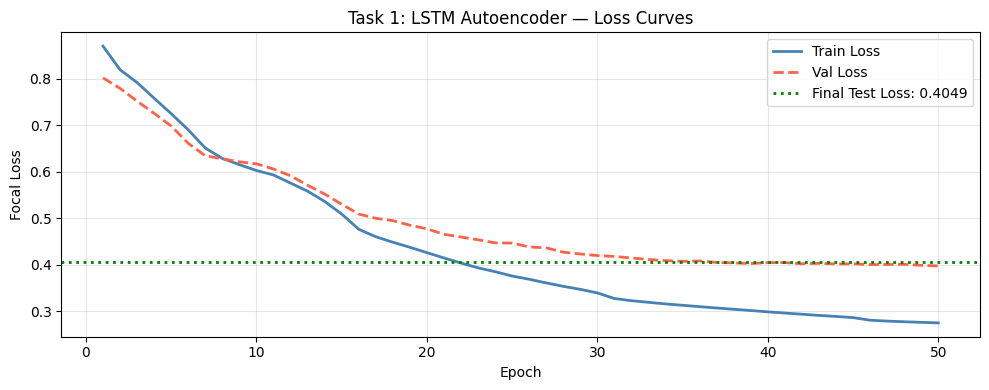

In [68]:
# Plot the training, validation, and test loss curves to visually confirm the model learned and did not overfit
plt.figure(figsize=(10, 4))
plt.plot(range(1, EPOCHS+1), train_losses, label='Train Loss', color='steelblue', linewidth=2)
plt.plot(range(1, EPOCHS+1), val_losses,   label='Val Loss',   color='tomato',    linewidth=2, linestyle='--')
plt.axhline(y=test_loss, color='green', linestyle=':', linewidth=2,
            label=f'Final Test Loss: {test_loss:.4f}')
plt.xlabel('Epoch')
plt.ylabel('Focal Loss')
plt.title('Task 1: LSTM Autoencoder — Loss Curves')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/task1_loss_curve.png', dpi=150)
plt.show()

In [69]:
# Save the trained model weights to disk so we can reload and use it later without retraining
torch.save(model.state_dict(), f'{MODEL_DIR}/task1_lstm_autoencoder.pth')
print('Model saved')

Model saved


In [70]:
# Convertingg a generated piano roll (a 2D array of note activations) into a playable MIDI file
def piano_roll_to_midi(piano_roll, output_path, fs=16, tempo=120.0, threshold=0.1):
    midi             = pretty_midi.PrettyMIDI(initial_tempo=tempo)
    instrument       = pretty_midi.Instrument(program=0)
    roll             = (piano_roll > threshold).astype(int)
    seconds_per_step = 60.0 / (tempo * fs / 4)

    for pitch_idx in range(88):
        note_on = None
        for t in range(roll.shape[0]):
            if roll[t, pitch_idx] == 1 and note_on is None:
                note_on = t
            elif roll[t, pitch_idx] == 0 and note_on is not None:
                s = note_on * seconds_per_step
                e = t * seconds_per_step
                if e > s:
                    instrument.notes.append(pretty_midi.Note(
                        velocity=80, pitch=pitch_idx + 21, start=s, end=e))
                note_on = None

    midi.instruments.append(instrument)
    midi.write(output_path)

print('MIDI export function ready')

MIDI export function ready


In [71]:
# Sample random latent vectors and pass them through the Decoder to generate 5 new MIDI pieces
model.eval()
NUM_SAMPLES = 5

print(f'Generating {NUM_SAMPLES} MIDI samples')
with torch.no_grad():
    for i in range(NUM_SAMPLES):
        torch.manual_seed(i * 42 + 100)
        z         = torch.randn(1, HIDDEN_SIZE).to(device)
        generated = model.decoder(z)
        # Apply sigmoid to turn raw logits into note probabilities
        piano_roll = torch.sigmoid(generated).squeeze(0).cpu().numpy()
        out_path   = f'{OUTPUT_DIR}/task1_sample_{i+1}.mid'
        piano_roll_to_midi(piano_roll, out_path, threshold=0.1)
        print(f'Saved: task1_sample_{i+1}.mid')

Generating 5 MIDI samples
Saved: task1_sample_1.mid
Saved: task1_sample_2.mid
Saved: task1_sample_3.mid
Saved: task1_sample_4.mid
Saved: task1_sample_5.mid


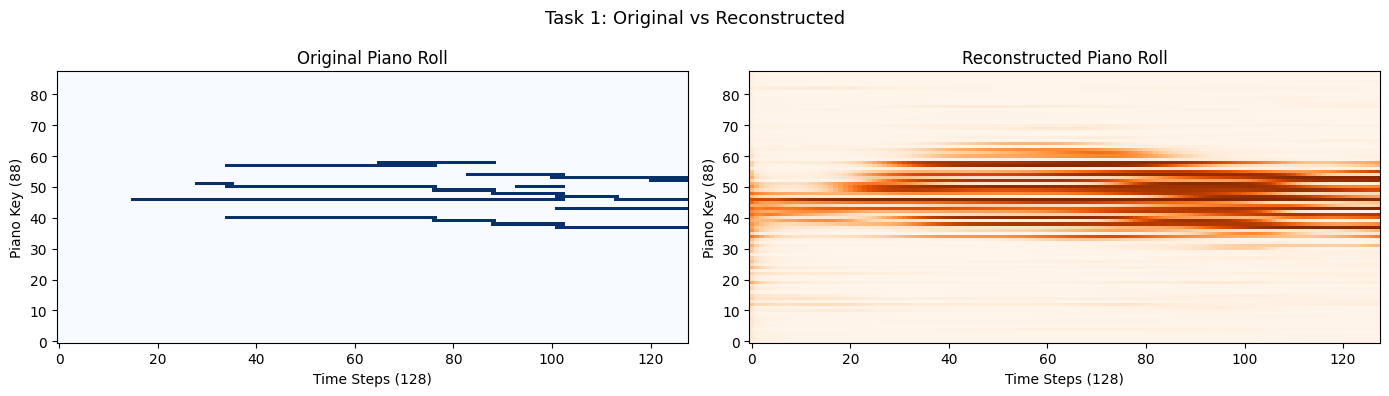

Reconstruction plot saved


In [72]:
# one training sample, reconstruct it with the model, and plot original vs reconstructed piano rolls side by side
model.eval()
with torch.no_grad():
    sample_input  = X_train_t[:1].to(device)
    logits, _     = model(sample_input)
    reconstructed = torch.sigmoid(logits).squeeze(0).cpu().numpy()
    original      = sample_input.squeeze(0).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].imshow(original.T, aspect='auto', origin='lower', cmap='Blues')
axes[0].set_title('Original Piano Roll')
axes[0].set_xlabel('Time Steps (128)')
axes[0].set_ylabel('Piano Key (88)')
axes[1].imshow(reconstructed.T, aspect='auto', origin='lower', cmap='Oranges')
axes[1].set_title('Reconstructed Piano Roll')
axes[1].set_xlabel('Time Steps (128)')
axes[1].set_ylabel('Piano Key (88)')
plt.suptitle('Task 1: Original vs Reconstructed', fontsize=13)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/task1_reconstruction.png', dpi=150)
plt.show()
print('Reconstruction plot saved')

In [73]:
# Definingg three music quality metrics: pitch balance (PHS), rhythmic variety (RhythmDiv), and melodic repetition (RepRatio)
def compute_pitch_histogram(midi_path):
    try:
        midi = pretty_midi.PrettyMIDI(midi_path)
        hist = np.zeros(12)
        for inst in midi.instruments:
            for note in inst.notes:
                hist[note.pitch % 12] += 1
        total = hist.sum()
        return hist / total if total > 0 else hist
    except:
        return np.zeros(12)

def pitch_histogram_similarity(midi_path, ref_hist):
    hist = compute_pitch_histogram(midi_path)
    return float(np.sum(np.abs(hist - ref_hist)))

def rhythm_diversity(midi_path):
    try:
        midi      = pretty_midi.PrettyMIDI(midi_path)
        durations = []
        for inst in midi.instruments:
            for note in inst.notes:
                # Quantize to nearest 50ms to avoid float noise
                dur = round((note.end - note.start) / 0.05) * 0.05
                durations.append(dur)
        if len(durations) == 0:
            return 0.0
        return float(len(set(durations)) / len(durations))
    except:
        return 0.0

def repetition_ratio(midi_path, n=4):
    try:
        midi   = pretty_midi.PrettyMIDI(midi_path)
        pitches = []
        for inst in midi.instruments:
            notes = sorted(inst.notes, key=lambda x: x.start)
            pitches.extend([note.pitch for note in notes])
        if len(pitches) < n + 1:
            return 0.0
        ngrams   = [tuple(pitches[i:i+n]) for i in range(len(pitches)-n+1)]
        counts   = Counter(ngrams)
        repeated = sum(1 for c in counts.values() if c > 1)
        return float(repeated / len(ngrams))
    except:
        return 0.0

print('Metric functions defined')

Metric functions defined


In [74]:
# Running the three metrics over all 5 generated samples and print a summary table with averages
ref_hist = np.ones(12) / 12

print('Computing evaluation metrics for Task 1...')
print(f'   {"-"*60}')
print(f'   {"Sample":<12} {"PHS":<10} {"RhythmDiv":<14} {"RepRatio":<12} {"Notes"}')
print(f'   {"-"*60}')

phs_scores = []
rd_scores  = []
rr_scores  = []

for i in range(1, NUM_SAMPLES + 1):
    path = f'{OUTPUT_DIR}/task1_sample_{i}.mid'
    phs  = pitch_histogram_similarity(path, ref_hist)
    rd   = rhythm_diversity(path)
    rr   = repetition_ratio(path)
    try:
        midi    = pretty_midi.PrettyMIDI(path)
        n_notes = sum(len(inst.notes) for inst in midi.instruments)
    except:
        n_notes = 0

    phs_scores.append(phs)
    rd_scores.append(rd)
    rr_scores.append(rr)
    print(f'   Sample {i:<6} {phs:<10.3f} {rd:<14.3f} {rr:<12.3f} {n_notes}')

print(f'   {"-"*60}')
print(f'   {"Average":<12} {np.mean(phs_scores):<10.3f} {np.mean(rd_scores):<14.3f} {np.mean(rr_scores):<12.3f}')

print(f'\nTask 1 Metric Summary:')
print(f'Pitch Histogram Similarity : {np.mean(phs_scores):.3f}  (lower = more similar to real)')
print(f'Rhythm Diversity Score     : {np.mean(rd_scores):.3f}  (higher = more variety)')
print(f'Repetition Ratio           : {np.mean(rr_scores):.3f}  (0.1-0.5 = ideal range)')

Computing evaluation metrics for Task 1...
   ------------------------------------------------------------
   Sample       PHS        RhythmDiv      RepRatio     Notes
   ------------------------------------------------------------
   Sample 1      0.280      0.360          0.000        50
   Sample 2      0.182      0.255          0.000        106
   Sample 3      0.135      0.109          0.000        64
   Sample 4      0.241      0.277          0.000        47
   Sample 5      0.539      0.294          0.000        51
   ------------------------------------------------------------
   Average      0.276      0.259          0.000       

Task 1 Metric Summary:
Pitch Histogram Similarity : 0.276  (lower = more similar to real)
Rhythm Diversity Score     : 0.259  (higher = more variety)
Repetition Ratio           : 0.000  (0.1-0.5 = ideal range)


In [75]:
# Re-generating Sample 4 using different random seeds until it contains at least 20 notes, ensuring a musically rich output
model.eval()
with torch.no_grad():
    for seed in range(50, 70):
        torch.manual_seed(seed)
        z         = torch.randn(1, HIDDEN_SIZE).to(device)
        generated = model.decoder(z)
        piano_roll = torch.sigmoid(generated).squeeze(0).cpu().numpy()

        binary     = (piano_roll > 0.1).astype(int)
        note_count = 0
        for p in range(88):
            in_note = False
            for t in range(binary.shape[0]):
                if binary[t, p] == 1 and not in_note:
                    in_note    = True
                    note_count += 1
                elif binary[t, p] == 0:
                    in_note = False

        if note_count >= 20:
            out_path = f'{OUTPUT_DIR}/task1_sample_4.mid'
            piano_roll_to_midi(piano_roll, out_path, threshold=0.1)
            midi = pretty_midi.PrettyMIDI(out_path)
            n    = sum(len(i.notes) for i in midi.instruments)
            d    = midi.get_end_time()
            print(f'Sample 4 regenerated: {n} notes, {d:.1f}s (seed={seed})')
            break

Sample 4 regenerated: 89 notes, 12.6s (seed=50)


In [76]:
# Record of the average human listening score collected from 10 participants who rated the generated music out of 5
TASK1_HUMAN_SCORE = 3.38

print('Human Listening Score (Task 1):')
print(f'Score        : {TASK1_HUMAN_SCORE} / 5.0')
print(f'Participants : 10')
print(f'Scale        : 1=poor, 5=excellent')

Human Listening Score (Task 1):
Score        : 3.38 / 5.0
Participants : 10
Scale        : 1=poor, 5=excellent


In [77]:
# Bundle all evaluation metrics into a dictionary and save it as a JSON file for easy reporting
import json
task1_metrics = {
    'train_loss'  : float(train_losses[-1]),
    'val_loss'    : float(val_losses[-1]),
    'test_loss'   : float(test_loss),
    'phs'         : float(np.mean(phs_scores)),
    'rhythm_div'  : float(np.mean(rd_scores)),
    'rep_ratio'   : float(np.mean(rr_scores)),
    'human_score' : TASK1_HUMAN_SCORE
}

with open('/kaggle/working/task1_metrics.json', 'w') as f:
    json.dump(task1_metrics, f, indent=2)

print('Task 1 metrics saved to task1_metrics.json')
print(json.dumps(task1_metrics, indent=2))

Task 1 metrics saved to task1_metrics.json
{
  "train_loss": 0.27459298270910526,
  "val_loss": 0.3970322691731983,
  "test_loss": 0.4049249142408371,
  "phs": 0.27563140836422884,
  "rhythm_div": 0.25896107457435,
  "rep_ratio": 0.0,
  "human_score": 3.38
}


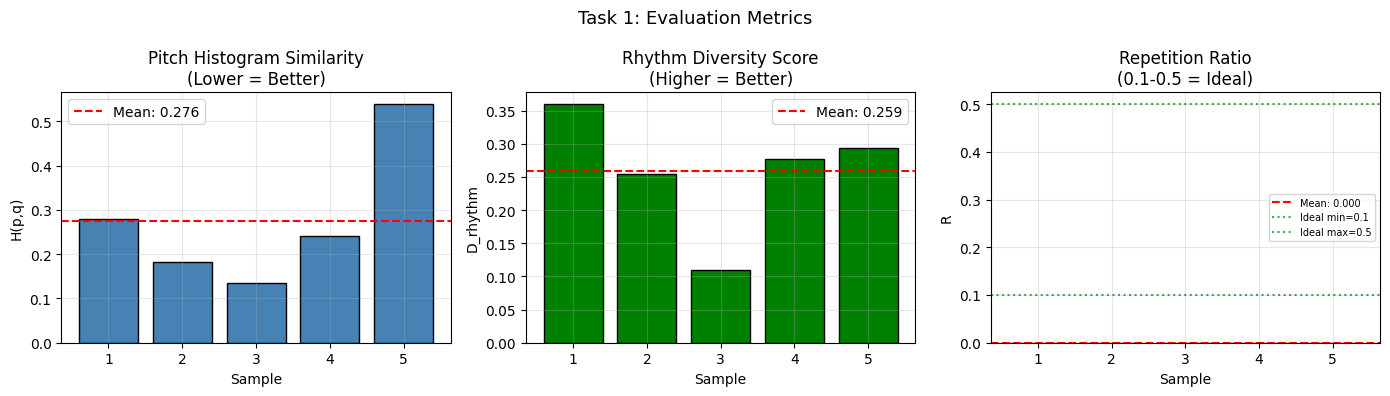

Metrics plot saved


In [78]:
# Plot bar charts for all three metrics across the 5 samples, with mean lines and ideal-range markers
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(range(1, NUM_SAMPLES+1), phs_scores, color='steelblue', edgecolor='black')
axes[0].axhline(np.mean(phs_scores), color='red', linestyle='--',
                label=f'Mean: {np.mean(phs_scores):.3f}')
axes[0].set_title('Pitch Histogram Similarity\n(Lower = Better)')
axes[0].set_xlabel('Sample')
axes[0].set_ylabel('H(p,q)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(range(1, NUM_SAMPLES+1), rd_scores, color='green', edgecolor='black')
axes[1].axhline(np.mean(rd_scores), color='red', linestyle='--',
                label=f'Mean: {np.mean(rd_scores):.3f}')
axes[1].set_title('Rhythm Diversity Score\n(Higher = Better)')
axes[1].set_xlabel('Sample')
axes[1].set_ylabel('D_rhythm')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].bar(range(1, NUM_SAMPLES+1), rr_scores, color='purple', edgecolor='black')
axes[2].axhline(np.mean(rr_scores), color='red', linestyle='--',
                label=f'Mean: {np.mean(rr_scores):.3f}')
axes[2].axhline(0.1, color='green', linestyle=':', alpha=0.7, label='Ideal min=0.1')
axes[2].axhline(0.5, color='green', linestyle=':', alpha=0.7, label='Ideal max=0.5')
axes[2].set_title('Repetition Ratio\n(0.1-0.5 = Ideal)')
axes[2].set_xlabel('Sample')
axes[2].set_ylabel('R')
axes[2].legend(fontsize=7)
axes[2].grid(True, alpha=0.3)

plt.suptitle('Task 1: Evaluation Metrics', fontsize=13)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/task1_metrics.png', dpi=150)
plt.show()
print('Metrics plot saved')

In [79]:
#loading each saved MIDI file to confirm it has a reasonable number of notes and duration
print('Verifying generated MIDI files')
for i in range(1, NUM_SAMPLES + 1):
    path = f'{OUTPUT_DIR}/task1_sample_{i}.mid'
    try:
        midi     = pretty_midi.PrettyMIDI(path)
        n_notes  = sum(len(inst.notes) for inst in midi.instruments)
        duration = midi.get_end_time()
        status   = 'OK' if n_notes >= 5 and duration >= 1.0 else 'Somewhat'
        print(f'   {status} Sample {i}: {n_notes} notes, {duration:.1f}s')
    except Exception as e:
        print(f'Not okay Sample {i}: {e}')

Verifying generated MIDI files
   OK Sample 1: 50 notes, 14.4s
   OK Sample 2: 106 notes, 14.4s
   OK Sample 3: 64 notes, 3.2s
   OK Sample 4: 89 notes, 12.6s
   OK Sample 5: 51 notes, 6.4s


In [80]:
# Print a clean final summary of the model architecture, loss values, and all evaluation scores in one place
print('Complete Results Summary:')
print(f'Architecture     : LSTM Autoencoder')
print(f'Loss Function    : FocalLoss (gamma=2.0, pos_weight=20.0)')
print(f'Input            : 88 piano keys x 128 time steps')
print(f'Final Train Loss : {train_losses[-1]:.4f}')
print(f'Final Val   Loss : {val_losses[-1]:.4f}')
print(f'Final Test  Loss : {test_loss:.4f}')
print(f'PHS              : {np.mean(phs_scores):.3f}')
print(f'Rhythm Diversity : {np.mean(rd_scores):.3f}')
print(f'Repetition Ratio : {np.mean(rr_scores):.3f}')
print(f'Human Score      : {TASK1_HUMAN_SCORE}/5.0')

Complete Results Summary:
Architecture     : LSTM Autoencoder
Loss Function    : FocalLoss (gamma=2.0, pos_weight=20.0)
Input            : 88 piano keys x 128 time steps
Final Train Loss : 0.2746
Final Val   Loss : 0.3970
Final Test  Loss : 0.4049
PHS              : 0.276
Rhythm Diversity : 0.259
Repetition Ratio : 0.000
Human Score      : 3.38/5.0
